In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [16]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
tables = soup.find_all('table', {'class': 'wikitable'})

In [17]:
table = None
for t in tables:
    if 'Country' in t.text and 'Youth' in t.text:
      table = t
      break

In [18]:
rows = table.find_all('tr')
data = []
for row in rows[1:]:
  cols = row.find_all(['td', 'th'])
  cols = [ele.get_text(strip=True).replace('%','').replace('-','') for ele in cols]
  data.append(cols)

In [19]:
df = pd.DataFrame(data)
df = df[df[0].notnull()]
df = df.rename(columns={0:'Country', 1:'Year', 2:'Youth', 3:'Adult', 4:'Elderly', 5:'Total'})
df = df[['Country', 'Year', 'Youth', 'Adult', 'Elderly', 'Total']]
df.replace('', pd.NA, inplace = True)
df.dropna(thresh=3, inplace = True)
for col in ['Youth', 'Adult', 'Elderly', 'Total']:
  df[col] = pd.to_numeric(df[col], errors='coerce')
df.to_csv('global_literacy_data.csv', index = False)

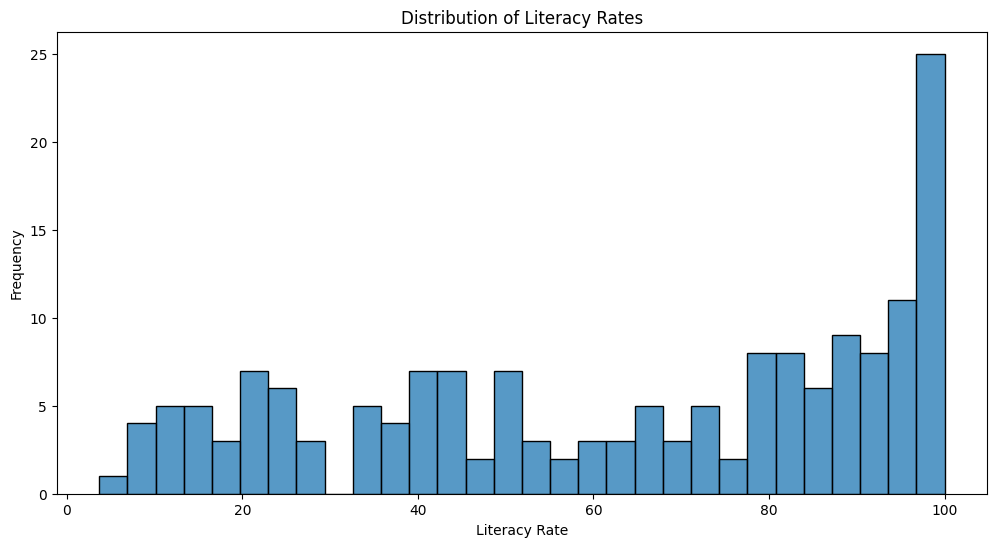

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('global_literacy_data.csv')
plt.figure(figsize=(12,6))
sns.histplot(df['Total'].dropna(), bins=30)
plt.title('Distribution of Literacy Rates')
plt.xlabel('Literacy Rate')
plt.ylabel('Frequency')
plt.show()

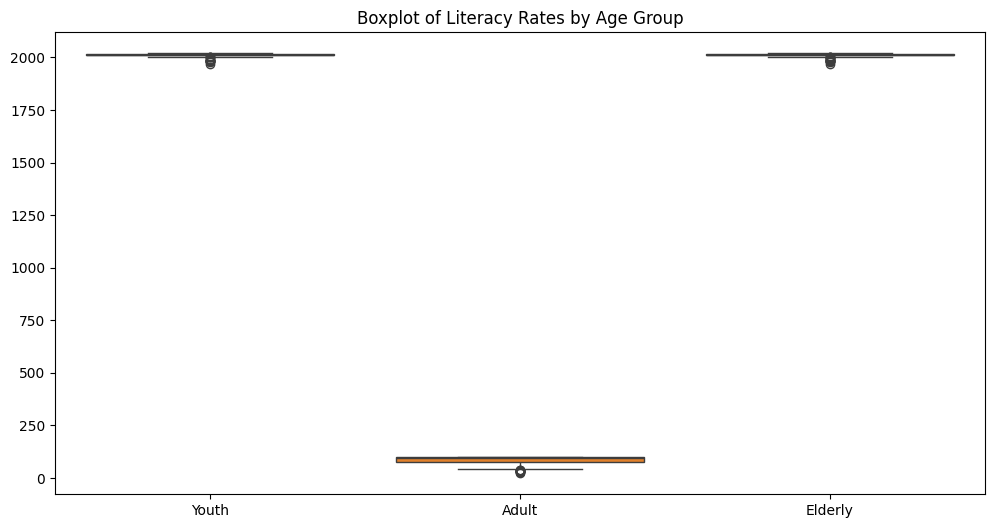

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Youth', 'Adult', 'Elderly']])
plt.title('Boxplot of Literacy Rates by Age Group')
plt.show()

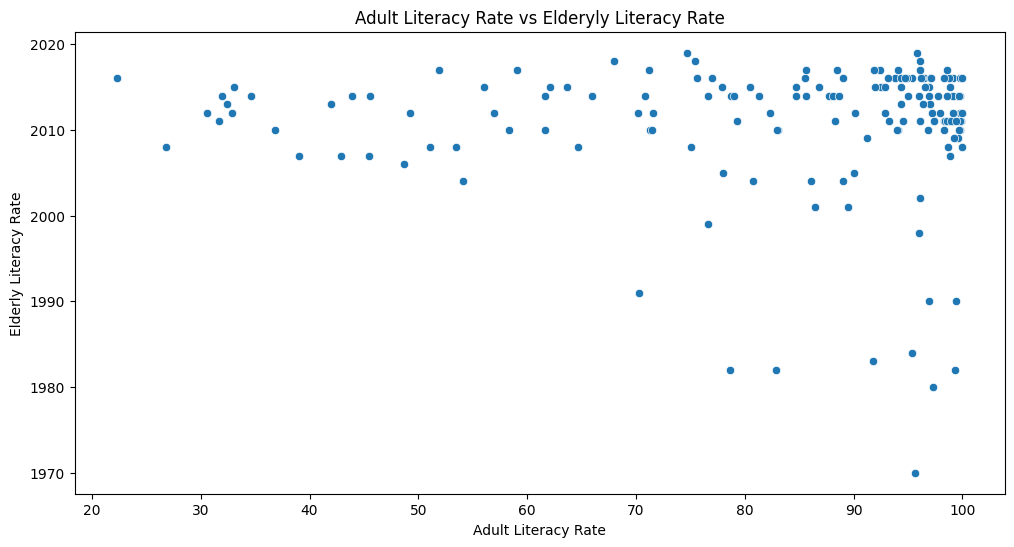

In [23]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Adult', y='Elderly')
plt.title('Adult Literacy Rate vs Elderyly Literacy Rate')
plt.xlabel('Adult Literacy Rate')
plt.ylabel('Elderly Literacy Rate')
plt.show()

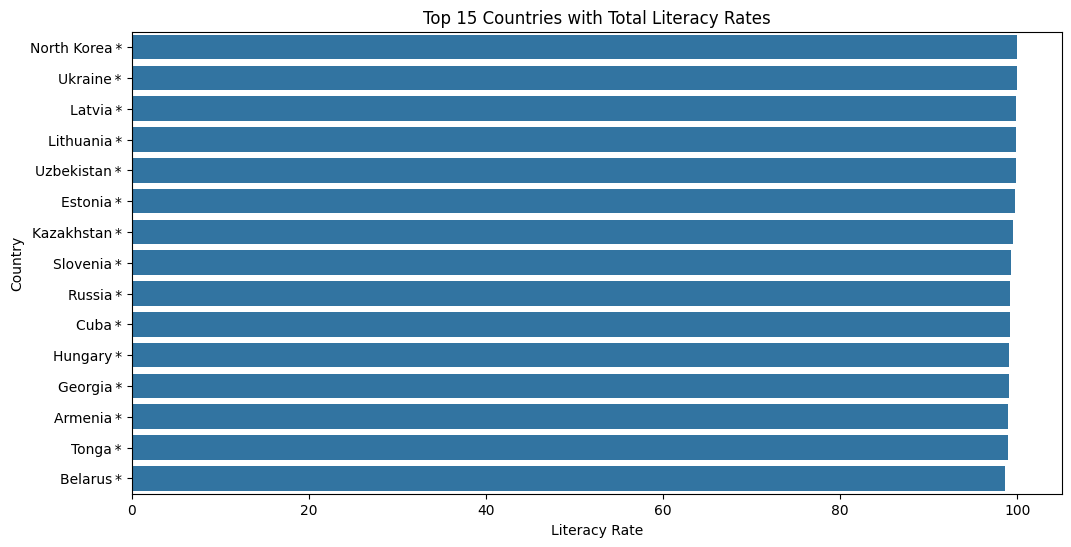

In [25]:
plt.figure(figsize=(12,6))
df_sorted = df.sort_values(by='Total', ascending=False).head(15)
sns.barplot(data=df_sorted, x='Total', y='Country')
plt.title('Top 15 Countries with Total Literacy Rates')
plt.xlabel('Literacy Rate')
plt.ylabel('Country')
plt.show()

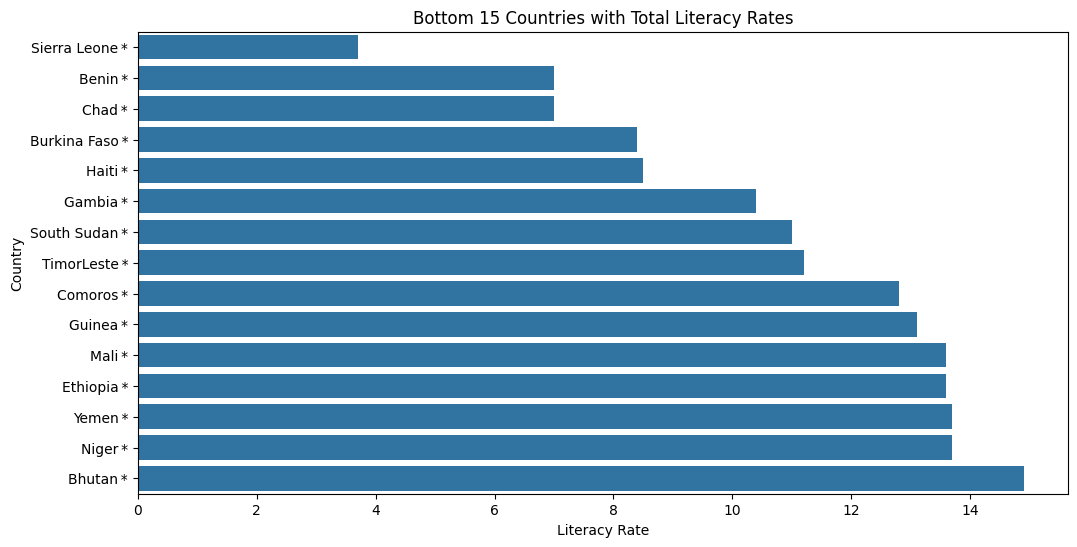

In [26]:
plt.figure(figsize=(12,6))
df_sorted = df.sort_values(by='Total', ascending=True).head(15)
sns.barplot(data=df_sorted, x='Total', y='Country')
plt.title('Bottom 15 Countries with Total Literacy Rates')
plt.xlabel('Literacy Rate')
plt.ylabel('Country')
plt.show()

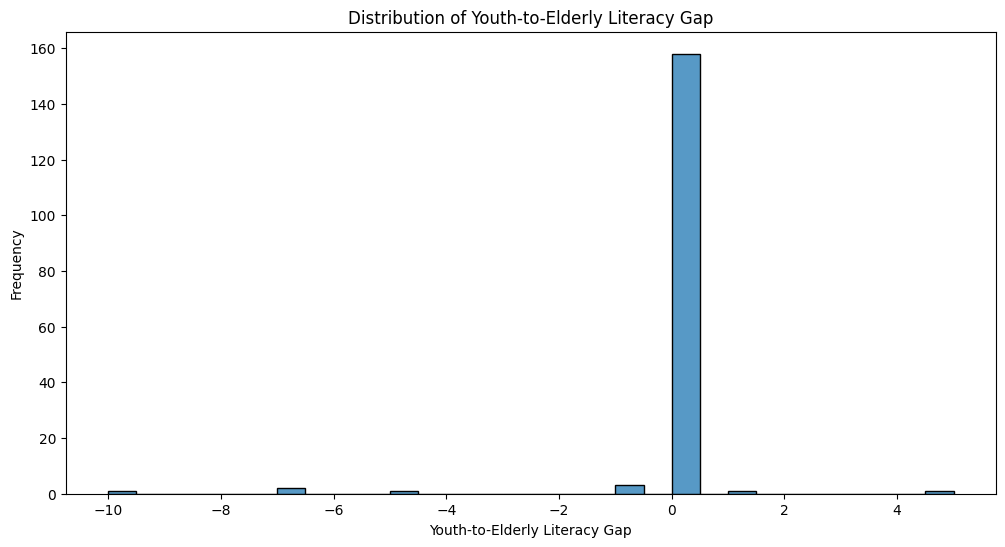

In [27]:
df['GenGap_Youth_Elderly'] = df['Youth'] - df['Elderly']
plt.figure(figsize=(12,6))
sns.histplot(df['GenGap_Youth_Elderly'].dropna(), bins=30)
plt.title('Distribution of Youth-to-Elderly Literacy Gap')
plt.xlabel('Youth-to-Elderly Literacy Gap')
plt.ylabel('Frequency')
plt.show()

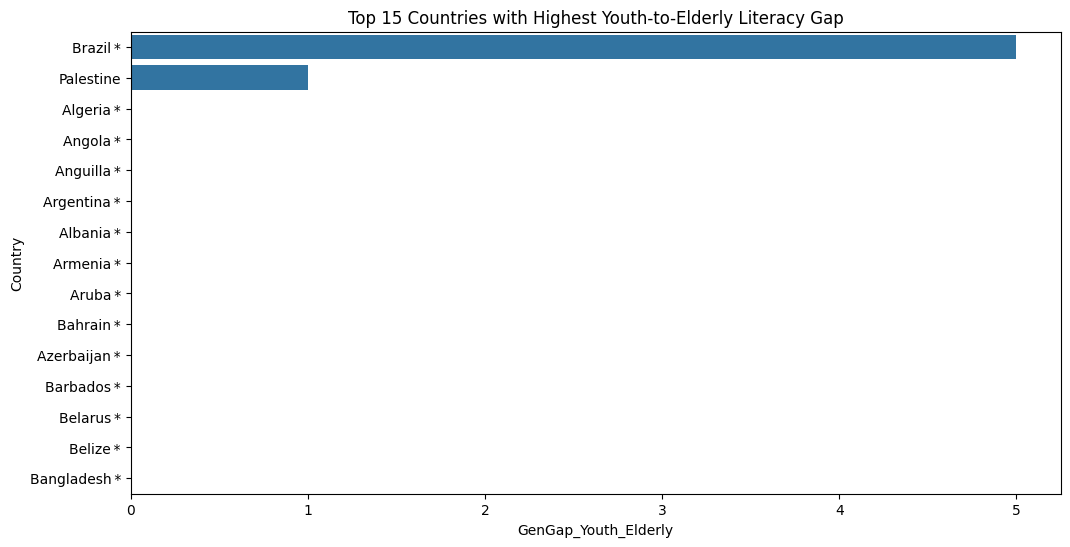

In [28]:
df_gap = df[['Country', 'GenGap_Youth_Elderly']].dropna().sort_values(by='GenGap_Youth_Elderly', ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(data=df_gap, x='GenGap_Youth_Elderly', y='Country')
plt.title('Top 15 Countries with Highest Youth-to-Elderly Literacy Gap')
plt.show()